## Imports and project setup

Import analysis libraries and project modules from `Synthetic/src`, then set the initial NumPy random seed.


In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import yaml
import random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import glob
import joblib

# Load project modules from Synthetic/src.
import sys
from pathlib import Path

src_path = Path("Synthetic/src")
if not src_path.is_dir():
    src_path = Path("../Synthetic/src")
src_path = src_path.resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import generator as gen_mod #gen_multi_steps_profiles lives only here
from generator import Agent as GenAgentBase        # used for the training-data bootstrap
from simulator import Bank, Agent as SimAgentBase, run_simulation
from evaluation import compute_statistics
from fair_model import FairModel
from baselines import LR, CvxFairModel, EOFairModel
from utils import combine_tuples

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Load the BAF datasets

Read all six local CSV files into `dataframes`, define dataset aliases, and create working copies of Base, Variant I, and Variant II.


In [2]:
# Reuse src_path, Path, and pd from the setup cell.
base_path = src_path.parents[1] / "local"
extension = "csv"

datasets_paths = {
    name: base_path / f"{name}.{extension}"
    for name in ["Base", "Variant I", "Variant II", "Variant III", "Variant IV", "Variant V"]
}

def read_dataset(path, ext=extension):
    if ext == "csv":
        return pd.read_csv(path)
    elif ext == "parquet":
        return pd.read_parquet(path)
    else:
        raise ValueError(f"Unsupported file extension: {ext}")

def get_variant(path):
    return Path(path).stem

data_paths = list(datasets_paths.values())
dataframes = {get_variant(path): read_dataset(path) for path in data_paths}
print(f"Loaded datasets: {list(dataframes.keys())}")

# Rename datasets
base = dataframes['Base']
variant1 = dataframes['Variant I']
variant2 = dataframes['Variant II']
variant3 = dataframes['Variant III']
variant4 = dataframes['Variant IV']
variant5 = dataframes['Variant V']

# For better display
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

dfs = [base, variant1, variant2, variant3, variant4, variant5]

# Datasets used to compare group size (gs) and fraud prevalence (pr)
base_df = base.copy()  # majority: 77% gs, 0.9% pr; minority: 23% gs, 1.8% pr
v1_df = variant1.copy()  # majority: 90% gs, 1.1% pr; minority: 10% gs, 1.1% pr
v2_df = variant2.copy()  # majority: 50% gs, 0.4% pr; minority: 50% gs, 1.9% pr


Loaded datasets: ['Base', 'Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V']


## Select the working columns

Keep fraud labels, age, income, credit risk score, and proposed credit limit for the three datasets. The simulation later uses only the two credit features.


In [3]:
v1_simple = v1_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()
v2_simple = v2_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()
base_simple = base_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()

## Define age groups

Set `S=0` for applicants younger than 50 and `S=1` for applicants aged 50 or above.


In [4]:
def add_age_group(df):
  df = df.copy()
  df['S'] = (df['customer_age'] >= 50).astype(int) # 1 = older minority
  return df

base_simple = add_age_group(base_simple)
v1_simple = add_age_group(v1_simple)
v2_simple = add_age_group(v2_simple)

## Inspect group sizes and fraud prevalence

Report each age group’s population share and fraud rate, plus the ratio of the higher to the lower fraud rate.


In [5]:
def group_stats(df,name):
  size = df['S'].value_counts(normalize=True) * 100
  rate0 = df.loc[df['S'] == 0, 'fraud_bool'].mean() * 100
  rate1 = df.loc[df['S'] == 1, 'fraud_bool'].mean() * 100
  ratio = max(rate0, rate1) / min(rate0, rate1) if min(rate0, rate1) > 0 else float('nan')
  print(f"===={name}===")
  print(f"  Group sizes:   S=0 (Younger)={size.get(0,0):.2f}%   S=1 (Older)={size.get(1,0):.2f}%")
  print(f"  Fraud rates:   S=0={rate0:.3f}%   S=1={rate1:.3f}%   ratio={ratio:.2f}x")
  print()

group_stats(base_simple, "Base")
group_stats(v1_simple, "Variant I")
group_stats(v2_simple, "Variant II")

====Base===
  Group sizes:   S=0 (Younger)=81.70%   S=1 (Older)=18.30%
  Fraud rates:   S=0=0.825%   S=1=2.341%   ratio=2.84x

====Variant I===
  Group sizes:   S=0 (Younger)=88.93%   S=1 (Older)=11.07%
  Fraud rates:   S=0=1.089%   S=1=1.216%   ratio=1.12x

====Variant II===
  Group sizes:   S=0 (Younger)=49.42%   S=1 (Older)=50.58%
  Fraud rates:   S=0=0.364%   S=1=1.825%   ratio=5.01x



## Prepare all three simulation pools

Standardize the two credit features separately within each dataset. Keep clearly named feature arrays, age-group indicators, and fraud labels for Base, Variant I, and Variant II.


In [6]:
X_COLS = ['credit_risk_score', 'proposed_credit_limit']


def prepare_feature_pool(df):
    features = df[X_COLS].to_numpy(dtype=float)
    features = (features - features.mean(axis=0)) / features.std(axis=0)
    age_groups = df['S'].to_numpy(dtype=int)
    fraud_labels = df['fraud_bool'].to_numpy(dtype=int)
    assert features.shape[1] == 2
    return features, age_groups, fraud_labels


features_base, age_groups_base, fraud_labels_base = prepare_feature_pool(base_simple)
features_variant1, age_groups_variant1, fraud_labels_variant1 = prepare_feature_pool(v1_simple)
features_variant2, age_groups_variant2, fraud_labels_variant2 = prepare_feature_pool(v2_simple)


## Fit a repayment model for each dataset

Fit separate non-fraud logistic regressions for Base, Variant I, and Variant II. The bootstrap context temporarily supplies the matching parameters to the generator’s internal Bank and restores them afterward, so datasets do not share calibration state.


In [7]:
from contextlib import contextmanager


def fit_repayment_bank(features, age_groups, fraud_labels):
    calibration = LogisticRegression(max_iter=1000).fit(
        np.c_[age_groups, features], 1 - fraud_labels
    )
    params = np.r_[calibration.coef_[0], calibration.intercept_[0]]
    return Bank(params=params)


bank_base = fit_repayment_bank(features_base, age_groups_base, fraud_labels_base)
bank_variant1 = fit_repayment_bank(features_variant1, age_groups_variant1, fraud_labels_variant1)
bank_variant2 = fit_repayment_bank(features_variant2, age_groups_variant2, fraud_labels_variant2)


@contextmanager
def bootstrap_repayment_bank(repayment_bank):
    """Scope the generator's internal Bank to one dataset, then restore it."""
    previous_params = gen_mod.Bank.params
    gen_mod.Bank.params = repayment_bank.params.copy()
    try:
        yield
    finally:
        gen_mod.Bank.params = previous_params


for dataset_name, repayment_bank in [
    ('Base', bank_base), ('Variant I', bank_variant1), ('Variant II', bank_variant2)
]:
    print(f'{dataset_name}: calibrated Bank.params = {repayment_bank.params}')


Base: calibrated Bank.params = [-0.83753206 -0.40031058 -0.23351066  4.9216811 ]
Variant I: calibrated Bank.params = [ 0.11985788 -0.40920872 -0.25377356  4.67470202]
Variant II: calibrated Bank.params = [-1.44688712 -0.4105952  -0.2406258   5.72391208]


## Sample balanced initial populations

Define a shared initializer that samples equal numbers from the two age groups without replacement within each group, using the agent’s initialization seed.


In [8]:
class _BAFInitMixin:
    def __init__(self, s_pool, X_pool, n_samples, protect_ratio=0.5, eps=0.5,
                 base=(0.2, 1.0), seed=2021):
        super().__init__(n_samples=n_samples, protect_ratio=protect_ratio,
                          eps=eps, base=base, seed=seed)
        self._s_pool = s_pool
        self._X_pool = X_pool

    def gen_init_profile(self):
        rng = np.random.default_rng(self.seed)
        n0 = np.where(self._s_pool == 0)[0]
        n1 = np.where(self._s_pool == 1)[0]
        # sample exactly n_samples/2 from each group so the population fed
        # into the graph generator is EXACTLY balanced, regardless of how imbalanced the source pool is
        half = self.n_samples // 2
        idx0 = rng.choice(n0, size=half, replace=False)
        idx1 = rng.choice(n1, size=self.n_samples - half, replace=False)
        idx = np.concatenate([idx0, idx1])
        rng.shuffle(idx)
        s = self._s_pool[idx].astype(float)
        X = self._X_pool[idx].copy()
        return s, X




## Define the training agent

Extend the generator agent so each bootstrap feature transition is followed by credit-limit regeneration. The inherited bootstrap transition retains its approval-probability multiplier.


In [9]:
class BAFAgentGen(_BAFInitMixin, GenAgentBase):
    """Bootstrap transition followed by BAF credit-limit regeneration.
    """

    def gen_next_profile(self, s, X, model):
        X_next = super().gen_next_profile(s, X, model)
        return resync_credit_limit(X_next, np.random)


## Define the simulation agent

Combine the BAF population initializer with the simulator agent’s behavior, including its peer-rejection calculations.


In [10]:
class BAFAgentSim(_BAFInitMixin, SimAgentBase):
    """For simulator.run_simulation() the actual networked simulation."""
    pass


## Compare feature correlations

Print the correlation between credit risk score and proposed credit limit in Base, Variant I, and Variant II.


In [11]:
print("Base:", base_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])
print("V1:  ", v1_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])
print("V2:  ", v2_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])

Base: 0.6061414475223358
V1:   0.5993240360135544
V2:   0.6310108985445129


## Fit the credit-limit relationship

Store a pooled Base regression, residual spread, and Base conversion statistics in `CreditLimitCoupling`. Regenerate credit limits from credit scores with fresh Gaussian noise; this does not enforce a fixed correlation over time.


In [12]:
from dataclasses import dataclass
from sklearn.linear_model import LinearRegression


@dataclass
class CreditLimitCoupling:
    """Pooled Base regression and the original raw/standardized conversions."""

    model: LinearRegression
    residual_std: float
    credit_mean: float
    credit_std: float
    limit_mean: float
    limit_std: float
    credit_col: int = 0
    limit_col: int = 1

    @classmethod
    def fit(cls, df):
        credit = df['credit_risk_score']
        limit = df['proposed_credit_limit']
        model = LinearRegression().fit(credit.to_numpy().reshape(-1, 1), limit.to_numpy())
        residual_std = (limit - model.predict(credit.to_numpy().reshape(-1, 1))).std()
        return cls(model, residual_std, credit.mean(), credit.std(), limit.mean(), limit.std())

    def resync(self, X_next, rng):
        X_next = np.asarray(X_next, dtype=float)
        credit_raw = X_next[:, self.credit_col] * self.credit_std + self.credit_mean
        predicted_limit_raw = self.model.predict(credit_raw.reshape(-1, 1))
        noise = rng.normal(0, self.residual_std, size=len(credit_raw))
        limit_raw = predicted_limit_raw + noise
        X_next = X_next.copy()
        X_next[:, self.limit_col] = (limit_raw - self.limit_mean) / self.limit_std
        return X_next


# Retain Base statistics even when the initial pool uses another variant.
credit_limit_coupling = CreditLimitCoupling.fit(base_simple)


def resync_credit_limit(X_next, rng):
    """Regenerate limits for all rows, including inactive applicants, as before."""
    return credit_limit_coupling.resync(X_next, rng)


## Update features during evaluation

Apply group-specific drift to continuing applicants and repayment-dependent changes to approved applicants. Then regenerate credit limits for all rows, including inactive applicants, preserving the current behavior.


In [13]:
def update_features(s, X, Y, D, continue_mask, agent, decision_model, rng):
    """Evaluation transition; retain group drift and the original resync scope."""
    X_next = np.asarray(X, dtype=float).copy()
    drift = np.asarray(agent.base, dtype=float)[s.astype(int)]
    X_next[continue_mask] += drift[continue_mask, None]

    approved = continue_mask & (D == 1)
    theta = np.asarray(decision_model.params[1:-1], dtype=float)
    repayment_sign = 2.0 * Y[approved] - 1.0
    X_next[approved] += (agent.eps * theta) * repayment_sign[:, None]

    # Retain the original overwrite of provisional limits for every applicant.
    return resync_credit_limit(X_next, rng)


## Define the shared simulation loop

Build a fixed social graph, sample decisions and repayment outcomes, update participation and features, and record trajectories. `enable_opt_out` controls population exit; `run_simulation_resynced` enables it. Callers control the NumPy random seed.


In [14]:
from graph import gen_static_demographic_regular_graph, gen_static_random_graph
from utils import sampling as _sampling

def run_simulation_baf(decision_model, agent, steps, *, repayment_model=None,
                             enforce_demographic_mixing=True, k=10, k_same=6, k_other=4,
                             directed=False, graph_seed=2026, seed=2026,
                             decision_coef=0.8, repayment_coef=0.8,
                             enable_opt_out=True):
    """Shared evaluation loop, with optional population opt-out.

    As before, callers seed np.random; seed is retained for compatibility.
    Bootstrap training intentionally keeps its different generator transition.
    """
    if repayment_model is None:
        repayment_model = Bank()

    s, X = agent.gen_init_profile()
    s = np.asarray(s).astype(int); X = np.asarray(X, dtype=float); n = len(s)

    if enforce_demographic_mixing:
        adj, edges = gen_static_demographic_regular_graph(s, k_same=int(k_same), k_other=int(k_other), seed=int(graph_seed))
    else:
        adj, edges = gen_static_random_graph(n, k=int(k), seed=int(graph_seed), directed=bool(directed))

    _, p_y = repayment_model.predict(s, X)
    Y = _sampling(np.asarray(p_y, dtype=float), values=[0.0, 1.0], coef=float(repayment_coef)).astype(int)

    active = np.ones(n, dtype=int)
    prev_denied = np.zeros(n, dtype=int)
    Xs, Ys = [X], [Y]
    Ds, Ps, Os, Us, As = [], [], [], [], []

    for t in range(int(steps)):
        X_t, Y_t, A_t, P_t = Xs[-1], Ys[-1], active, prev_denied
        _, p_dec = decision_model.predict(s, X_t)
        D_t = _sampling(np.asarray(p_dec, dtype=float), values=[0.0, 1.0], coef=float(decision_coef)).astype(int)
        D_t[A_t == 0] = -1
        denied = ((A_t == 1) & (D_t == 0)).astype(int)

        O_t = agent.compute_observed_rejection_gap(adj, D_t, s, active=A_t, exclude_inactive_from_denominator=True)

        if enable_opt_out:
            repeated_denial = (denied == 1) & (P_t == 1)
            peer_spillover = (denied == 1) & (O_t == 1)
            U_t = ((repeated_denial | peer_spillover) & (A_t == 1)).astype(int)
        else:
            U_t = np.zeros(n, dtype=int)

        A_next = A_t.copy()
        A_next[(U_t == 1) & (A_t == 1)] = 0

        continue_mask = (A_t == 1) & (A_next == 1)
        X_next = update_features(
            s, X_t, Y_t, D_t, continue_mask, agent, decision_model, np.random
        )

        Y_next = np.asarray(Y_t, dtype=int).copy()
        if continue_mask.any():
            _, p_y_next = repayment_model.predict(s, X_next)
            Y_sample = _sampling(np.asarray(p_y_next, dtype=float), values=[0.0, 1.0], coef=float(repayment_coef)).astype(int)
            Y_next[continue_mask] = Y_sample[continue_mask]

        P_next = denied.copy()
        P_next[A_next == 0] = 0

        Ds.append(D_t); Os.append(O_t); Us.append(U_t); As.append(A_t.copy()); Ps.append(P_t.copy())
        active, prev_denied = A_next, P_next
        if t < steps - 1: Xs.append(X_next); Ys.append(Y_next)

    return s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As

def run_simulation_resynced(decision_model, agent, steps, **kwargs):
    """Compatibility entry point with opt-out enabled."""
    return run_simulation_baf(
        decision_model, agent, steps, enable_opt_out=True, **kwargs
    )


## Configure agents for all three datasets

Create separate training and evaluation agents for each dataset, retaining the same population sizes, group drift, and seeds. The `experiments` dictionary keeps each dataset’s bank, agents, models, and results together.


In [15]:
def create_dataset_agents(features, age_groups):
    train_agent = BAFAgentGen(age_groups, features, n_samples=4000, eps=0.5, base=[0.2, 1.0], seed=2026)
    test_agent = BAFAgentSim(age_groups, features, n_samples=1000, eps=0.5, base=[0.2, 1.0], seed=2027)
    return train_agent, test_agent


agent_train_base, agent_test_base = create_dataset_agents(features_base, age_groups_base)
agent_train_variant1, agent_test_variant1 = create_dataset_agents(features_variant1, age_groups_variant1)
agent_train_variant2, agent_test_variant2 = create_dataset_agents(features_variant2, age_groups_variant2)

experiments = {
    'Base': {'bank': bank_base, 'train_agent': agent_train_base, 'test_agent': agent_test_base},
    'Variant I': {'bank': bank_variant1, 'train_agent': agent_train_variant1, 'test_agent': agent_test_variant1},
    'Variant II': {'bank': bank_variant2, 'train_agent': agent_train_variant2, 'test_agent': agent_test_variant2},
}


## Define the equal-opportunity constraint

Replace the EO constraint calculation with group-specific selections of positive-label examples using elementwise logical conjunction.


In [16]:
import cvxpy as cp

def fixed_eo_constraint(self, s, X, y):
  X = self.add_intercept(s, X)
  X_pos = X[(y == 1) & (s == 1)]   # true positives in group 1 (was: ==)
  X_neg = X[(y == 1) & (s == 0)]   # true positives in group 0
  n_pos = max(1, len(X_pos))       # guard against an empty slice
  n_neg = max(1, len(X_neg))
  h_pos = X_pos @ self.w
  h_neg = X_neg @ self.w
  c1 = 1.0/n_pos * cp.sum(cp.logistic(h_pos)) + 1.0/n_neg * cp.sum(cp.logistic(-h_neg))
  c2 = 1.0/n_pos * cp.sum(cp.logistic(-h_pos)) + 1.0/n_neg * cp.sum(cp.logistic(h_neg))
  return c1, c2

EOFairModel.compute_constraint = fixed_eo_constraint

## Train separate models for Base, Variant I, and Variant II

Run the same five-step bootstrap and LR, LCF, DP, and EO training procedure for each dataset. Keep the four trained models in `models_base`, `models_variant1`, and `models_variant2`; training settings are unchanged.


In [17]:
def train_dataset_models(bank, agent_train, *, lcf_initial_epochs=1000,
                         lcf_retraining_rounds=50, lcf_retraining_epochs=10):
    """Train independent models with this dataset's bootstrap repayment bank."""
    with bootstrap_repayment_bank(bank):
        s_train, Xs_train, Ys_train = gen_mod.gen_multi_step_profiles(bank, agent_train, steps=5)
        s_comb, X_comb, Y_comb = combine_tuples(s_train, Xs_train, Ys_train)
        d = X_comb.shape[1]

        # Baseline (LR)
        lr = LR(l2_reg=1e-5)
        lr.train(s_comb, X_comb, Y_comb)

        # Hu's LCF
        LCF = FairModel(n_features=d + 1, lr=5e-3, l2_reg=1e-5, sf_reg=0.119, lf_reg=0.154)
        LCF.train(s_train, Xs_train, Ys_train, Xs_train, Ys_train, epochs=lcf_initial_epochs, plot=False)

        num_iters = lcf_retraining_rounds
        for t in range(num_iters):
            _, NXs_train, NYs_train = gen_mod.gen_multi_step_profiles(LCF, agent_train, steps=5)
            LCF.train(s_train, Xs_train, Ys_train, NXs_train, NYs_train, epochs=lcf_retraining_epochs, plot=False)
        print("LCF Retraining Done!")

        # DP model
        dp_model = CvxFairModel(n_features=d + 1, l2_reg=1e-5, tao=1.565)
        dp_model.train(s_comb, X_comb, Y_comb)

        # EO model
        eo_model = EOFairModel(n_features=d + 2, l2_reg=1e-5, tao=1.5)
        eo_model.train(s_comb, X_comb, Y_comb)
        return {"Baseline": lr, "LCF": LCF, "EO": eo_model, "DP": dp_model}


models_base = train_dataset_models(bank_base, agent_train_base)
models_variant1 = train_dataset_models(bank_variant1, agent_train_variant1)
models_variant2 = train_dataset_models(bank_variant2, agent_train_variant2)

experiments['Base']['models'] = models_base
experiments['Variant I']['models'] = models_variant1
experiments['Variant II']['models'] = models_variant2


LCF Retraining Done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6619
[Fair Model with Equal Opportunity] status: optimal, loss: 0.6630
LCF Retraining Done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6597
[Fair Model with Equal Opportunity] status: optimal, loss: 0.6599
LCF Retraining Done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6505
[Fair Model with Equal Opportunity] status: optimal, loss: 0.6523


## Define evaluation across random seeds

Define helpers that run simulations with opt-out, report statistics and retention, and summarize the final recorded retention disparity across five seeds. The initial applicant sample remains fixed by the agent seed.


In [18]:
#identical to run_and_evaluate() but averaged over 5 seeds
def run_and_evaluate_seeded(model, model_name, bank, agent, steps=5, run_seed=2026):
    np.random.seed(run_seed)  # controls decision/outcome sampling + resync noise
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=run_seed,
        seed=run_seed,
        decision_coef=0.8,
        repayment_coef=0.8,
    )

    print(f"\n{'='*60}\n=== {model_name} (seed={run_seed}) ===\n{'='*60}")
    compute_statistics(s, Xs, Ds, model, OYs=Ys)

    print(f"\nRetention rates ({model_name}, seed={run_seed}):")
    s_arr = np.array(s)
    for t in range(len(As)):
        A_t = np.array(As[t])
        overall = np.mean(A_t) * 100
        r_s0 = np.mean(A_t[s_arr == 0]) * 100
        r_s1 = np.mean(A_t[s_arr == 1]) * 100
        disparity = abs(r_s0 - r_s1)
        print(f"Step {t+1}: Retention={overall:.1f}%, R(S=0)={r_s0:.1f}%, "
              f"R(S=1)={r_s1:.1f}%, Disparity={disparity:.1f}%")

    return s, Xs, Ys, Ds, As


def run_multiseed(model, model_name, bank, agent, steps=5, seeds=(2026, 7, 13, 42, 99)):
    disparities = []
    for sd in seeds:
        s, Xs, Ys, Ds, As = run_and_evaluate_seeded(model, model_name, bank, agent, steps, sd)
        s_arr = np.array(s)
        A_final = np.array(As[-1])
        r0 = A_final[s_arr == 0].mean() * 100
        r1 = A_final[s_arr == 1].mean() * 100
        disparities.append(abs(r0 - r1))
    return np.mean(disparities), np.std(disparities), disparities

## Compare final retention disparity

Run the seeded evaluation for each trained model and print the mean, standard deviation, and individual final retention disparities.


In [19]:
for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: final retention disparity ===')
    experiment['retention_disparity_summary'] = {}
    for model_name, model in experiment['models'].items():
        summary = run_multiseed(model, model_name, experiment['bank'], experiment['test_agent'])
        experiment['retention_disparity_summary'][model_name] = summary
        mean_d, std_d, all_d = summary
        print(f"{model_name}: {mean_d:.1f}% ± {std_d:.1f}% (runs: {[round(x, 1) for x in all_d]})")



=== Base: final retention disparity ===

=== Baseline (seed=2026) ===
------------------------------ Step 1 - Logistic Regression ------------------------------
Acc: 63.5%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 2 - Logistic Regression ------------------------------
Acc: 60.1%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.001
------------------------------ Step 3 - Logistic Regression ------------------------------
Acc: 61.2%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.048
------------------------------ Step 4 - Logistic Regression ------------------------------
Acc: 60.6%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.012
------------------------------ Step 5 - Logistic Regression ------------------------------
Acc: 60.1%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.283



Retention rates (Baseline, seed=2026):
Step 1: Retention=100.0%, R(S=0)=100.0%, R(S=1)=100.0%, Disparity=0.0%
S

## Define evaluation for plotted trajectories

Define a helper that runs opt-out simulations with a fixed graph seed and reports statistics and retention. This helper uses the current NumPy random state without resetting it.


In [20]:
#identical run_and_evaluate() from cloned_ltf_pop
def run_and_evaluate(model, model_name, bank, agent, steps=5):
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=2026,
        seed=2026,
        decision_coef=0.8,
        repayment_coef=0.8,
    )

    print(f"\n{'='*60}\n=== {model_name} ===\n{'='*60}")
    compute_statistics(s, Xs, Ds, model, OYs=Ys)

    print(f"\nRetention rates ({model_name}):")
    s_arr = np.array(s)
    for t in range(len(As)):
        A_t = np.array(As[t])
        overall = np.mean(A_t) * 100
        r_s0 = np.mean(A_t[s_arr == 0]) * 100
        r_s1 = np.mean(A_t[s_arr == 1]) * 100
        disparity = abs(r_s0 - r_s1)
        print(f"Step {t+1}: Retention={overall:.1f}%, R(S=0)={r_s0:.1f}%, "
              f"R(S=1)={r_s1:.1f}%, Disparity={disparity:.1f}%")

    return s, Xs, Ys, Ds, As


## Collect trajectories for each dataset

Run all four models with their matching bank and evaluation agent, and retain separate trajectory dictionaries for Base, Variant I, and Variant II.


In [21]:
def collect_dataset_trajectories(models, bank, test_agent):
    return {
        model_name: run_and_evaluate(model, model_name, bank, test_agent)
        for model_name, model in models.items()
    }


trajectories_base = collect_dataset_trajectories(models_base, bank_base, agent_test_base)
trajectories_variant1 = collect_dataset_trajectories(models_variant1, bank_variant1, agent_test_variant1)
trajectories_variant2 = collect_dataset_trajectories(models_variant2, bank_variant2, agent_test_variant2)

experiments['Base']['trajectories'] = trajectories_base
experiments['Variant I']['trajectories'] = trajectories_variant1
experiments['Variant II']['trajectories'] = trajectories_variant2



=== Baseline ===
------------------------------ Step 1 - Logistic Regression ------------------------------
Acc: 65.4%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 2 - Logistic Regression ------------------------------
Acc: 64.5%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.001
------------------------------ Step 3 - Logistic Regression ------------------------------
Acc: 62.5%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.044
------------------------------ Step 4 - Logistic Regression ------------------------------
Acc: 62.9%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.055
------------------------------ Step 5 - Logistic Regression ------------------------------
Acc: 61.8%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.089



Retention rates (Baseline):
Step 1: Retention=100.0%, R(S=0)=100.0%, R(S=1)=100.0%, Disparity=0.0%
Step 2: Retention=80.2%, R(S=0)=78.2%, R(S=1)=82.2%, Disparity=4.

## Define the simulation without opt-out

Provide a thin wrapper around the shared loop with population exit disabled. Feature dynamics remain enabled.


In [22]:
def run_simulation_no_dynamic(decision_model, agent, steps, **kwargs):
    """Disable population opt-out while retaining feature dynamics."""
    return run_simulation_baf(
        decision_model, agent, steps, enable_opt_out=False, **kwargs
    )


## Define the predictive-equality calculation

Compare group flagging rates among non-fraud-labelled applicants using a threshold derived from their predicted probabilities. The current code uses the `1 - target_fpr` quantile and flags probabilities below it.


In [23]:
def predictive_equality_at_fpr(model, s, X, y_true, target_fpr=0.05):
    _, p = model.predict(s, X)
    legit = y_true == 1
    if legit.sum() == 0: return np.nan
    thresh = np.quantile(p[legit], 1 - target_fpr)
    flagged = (p < thresh).astype(int)
    m0, m1 = legit & (s == 0), legit & (s == 1)
    if m0.sum() == 0 or m1.sum() == 0: return np.nan
    fpr0, fpr1 = flagged[m0].mean(), flagged[m1].mean()
    if max(fpr0, fpr1) == 0: return np.nan
    return min(fpr0, fpr1) / max(fpr0, fpr1)

## Import long-term fairness utilities

Load the functions used to estimate conditional probability ratios and compute long-term fairness.


In [24]:
import evaluation
from evaluation import compute_post_long_cond_fairness, compute_post_long_cond_probs

## Compute metrics from stored trajectories

Clip denominator probabilities in the conditional-ratio estimator, then extract retention, absolute long-term unfairness, and predictive-equality values. The long-term calculation uses full stored trajectories; predictive equality filters to active applicants.


In [25]:
# Patch compute_post_long_cond_probs to clip probabilities before dividing which prevents the ratio from exploding when BAF's rare fraud rate
# (~1%) pushes a denominator probability close to 0. Same idea as "propensity score trimming" in the causal inference literature.

def safe_compute_post_long_cond_probs(s, Xs, Ys, clip=0.05):
    probs = {}
    for i in range(len(Xs) - 1):
        for group_val, label in [(1, 'pos'), (0, 'neg')]:
            mask = s == group_val
            XXs_comb = np.c_[s[mask], Xs[i][mask], Xs[i + 1][mask]]
            Xs_comb = np.c_[s[mask], Xs[i][mask]]
            lr_up = LogisticRegression(max_iter=1000, random_state=2021).fit(XXs_comb, Ys[i][mask])
            lr_dn = LogisticRegression(max_iter=1000, random_state=2021).fit(Xs_comb, Ys[i][mask])
            probs_up = lr_up.predict_proba(XXs_comb)
            probs_dn = np.clip(lr_dn.predict_proba(Xs_comb), clip, 1 - clip)   # <-- the fix
            probs[f'{label}(y{i+1}=0)'] = probs_up[:, 0] / probs_dn[:, 0]
            probs[f'{label}(y{i+1}=1)'] = probs_up[:, 1] / probs_dn[:, 1]
    return probs

evaluation.compute_post_long_cond_probs = safe_compute_post_long_cond_probs
compute_post_long_cond_probs = safe_compute_post_long_cond_probs

def extract_metrics(result_tuple, model):
    s, Xs, Ys, Ds, As = result_tuple
    s_arr = np.array(s)
    ret_s0, ret_s1, disparity, unfairness, pred_equality = [], [], [], [], []
    for i in range(len(As)):
        A_t = np.array(As[i])
        r0 = A_t[s_arr == 0].mean() * 100
        r1 = A_t[s_arr == 1].mean() * 100
        ret_s0.append(r0); ret_s1.append(r1); disparity.append(abs(r0 - r1))
        if i == 0:
            plcf = compute_post_long_cond_fairness(s, Xs[:i+1], model)
        else:
            probs = compute_post_long_cond_probs(s, Xs[:i+1], Ys[:i+1])
            plcf = compute_post_long_cond_fairness(s, Xs[:i+1], model, probs)
        unfairness.append(abs(plcf))
        am = A_t == 1
        pred_equality.append(predictive_equality_at_fpr(model, s_arr[am], Xs[i][am], Ys[i][am]))
    return {'S=0': ret_s0, 'S=1': ret_s1, 'disparity': disparity,
            'unfairness': unfairness, 'pred_equality': pred_equality}


def extract_dataset_metrics(trajectories, models):
    return {name: extract_metrics(trajectories[name], model) for name, model in models.items()}


results_base = extract_dataset_metrics(trajectories_base, models_base)
results_variant1 = extract_dataset_metrics(trajectories_variant1, models_variant1)
results_variant2 = extract_dataset_metrics(trajectories_variant2, models_variant2)

experiments['Base']['metrics'] = results_base
experiments['Variant I']['metrics'] = results_variant1
experiments['Variant II']['metrics'] = results_variant2


## Collect results without opt-out

Run each model with population exit disabled and extract the same metrics for comparison with opt-out simulations.


In [26]:
def run_no_dynamic_and_extract(model, bank, test_agent):
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
        decision_model=model, repayment_model=bank, agent=test_agent, steps=5,
        enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False,
        graph_seed=2026, seed=2026, decision_coef=0.8, repayment_coef=0.8,
    )
    return extract_metrics((s, Xs, Ys, Ds, As), model)

def collect_no_opt_out_metrics(models, bank, test_agent):
    return {
        name: run_no_dynamic_and_extract(model, bank, test_agent)
        for name, model in models.items()
    }


results_no_opt_out_base = collect_no_opt_out_metrics(models_base, bank_base, agent_test_base)
results_no_opt_out_variant1 = collect_no_opt_out_metrics(models_variant1, bank_variant1, agent_test_variant1)
results_no_opt_out_variant2 = collect_no_opt_out_metrics(models_variant2, bank_variant2, agent_test_variant2)

experiments['Base']['metrics_no_opt_out'] = results_no_opt_out_base
experiments['Variant I']['metrics_no_opt_out'] = results_no_opt_out_variant1
experiments['Variant II']['metrics_no_opt_out'] = results_no_opt_out_variant2


## Plot retention by age group

Show each model’s group retention trajectories and annotate the average absolute retention disparity after the initial step.

Repeat the plot for all three datasets, label each figure, and prefix any saved filenames with the dataset name.


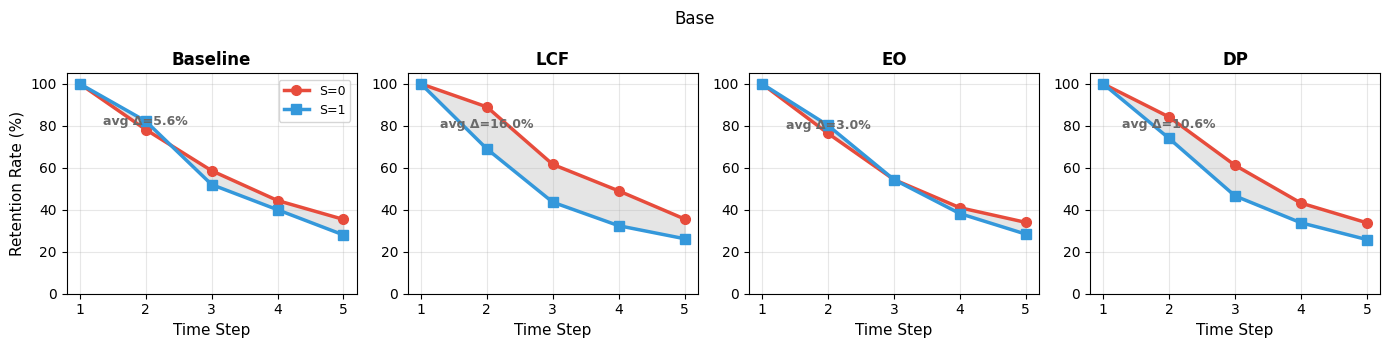

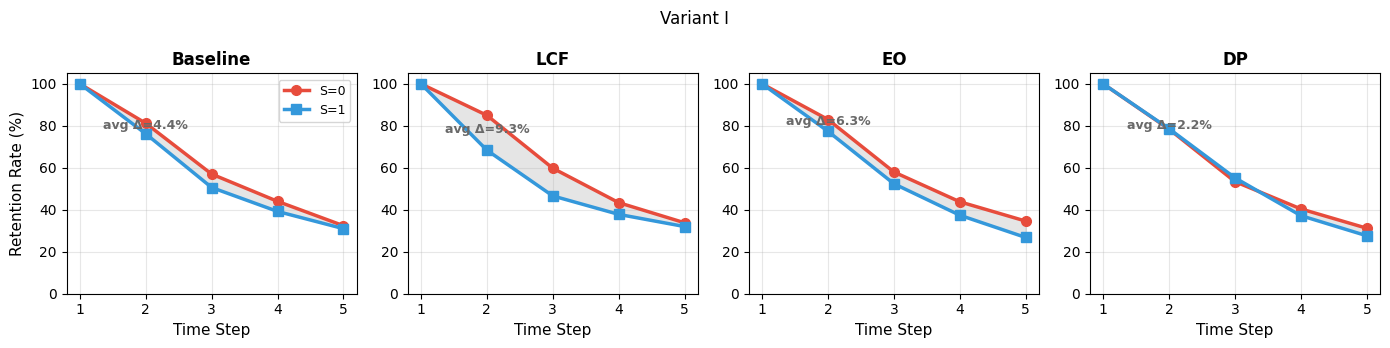

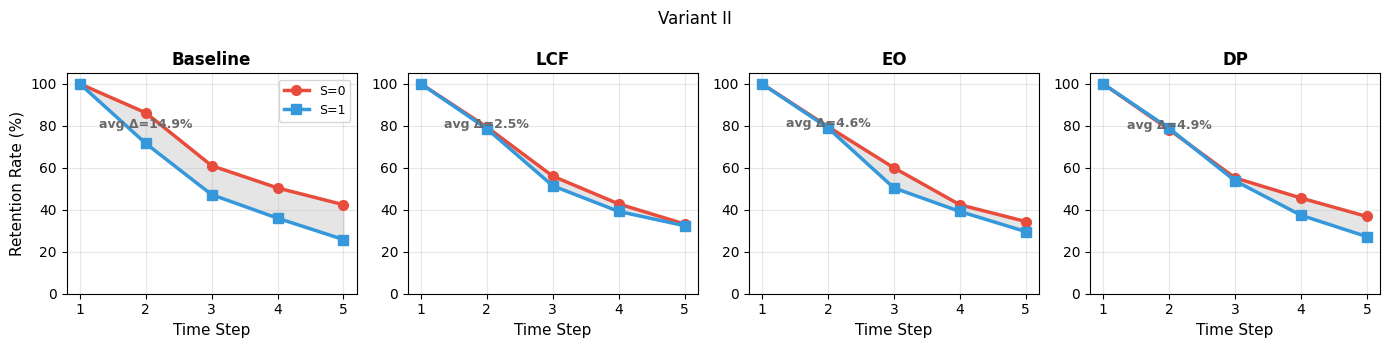

In [27]:
def plot_group_retention(dataset_name, experiment):
    results = experiment['metrics']
    results_no_dynamic = experiment['metrics_no_opt_out']
    all_metrics = experiment.get('detailed_metrics', {})
    steps = list(range(1, len(results['Baseline']['S=0']) + 1))
    methods = list(results)
    method_colors = {'Baseline': '#E74C3C', 'LCF': '#3498DB', 'EO': '#27AE60', 'DP': '#9B59B6'}
    dataset_slug = {'Base': 'base', 'Variant I': 'variant1', 'Variant II': 'variant2'}[dataset_name]
    #Figure 1 Retention rates by group (4-panel)
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    colors = {'S=0': '#E74C3C', 'S=1': '#3498DB'}

    methods = list(results.keys())
    for idx, method in enumerate(methods):
        ax = axes[idx]
        ax.plot(steps, results[method]['S=0'], 'o-', color=colors['S=0'], label='S=0', linewidth=2.5, markersize=7)
        ax.plot(steps, results[method]['S=1'], 's-', color=colors['S=1'], label='S=1', linewidth=2.5, markersize=7)
        ax.fill_between(steps, results[method]['S=0'], results[method]['S=1'], alpha=0.2, color='gray')

        #disparity_t2 = results[method]['disparity'][1]
        avg_disparity = np.mean(results[method]['disparity'][1:])   # skip step 1 which is always 0, average for t 2-5
        mid_y = (results[method]['S=0'][1] + results[method]['S=1'][1]) / 2
        ax.annotate(f'avg Δ={avg_disparity:.1f}%', xy=(2, mid_y), fontsize=9, ha='center', color='dimgray', fontweight='bold')

        ax.set_title(method, fontsize=12, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.set_xticks(steps)
        ax.set_xlabel('Time Step', fontsize=11)
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.set_ylabel('Retention Rate (%)', fontsize=11)
            ax.legend(loc='upper right', fontsize=9)

    fig.suptitle(dataset_name)
    plt.tight_layout()
    plt.show()

for dataset_name, experiment in experiments.items():
    plot_group_retention(dataset_name, experiment)


## Plot retention and relative retention

Overlay the `S=0/S=1` retention ratio on the group retention plots to show the direction as well as the size of participation differences.

Repeat the plot for all three datasets, label each figure, and prefix any saved filenames with the dataset name.


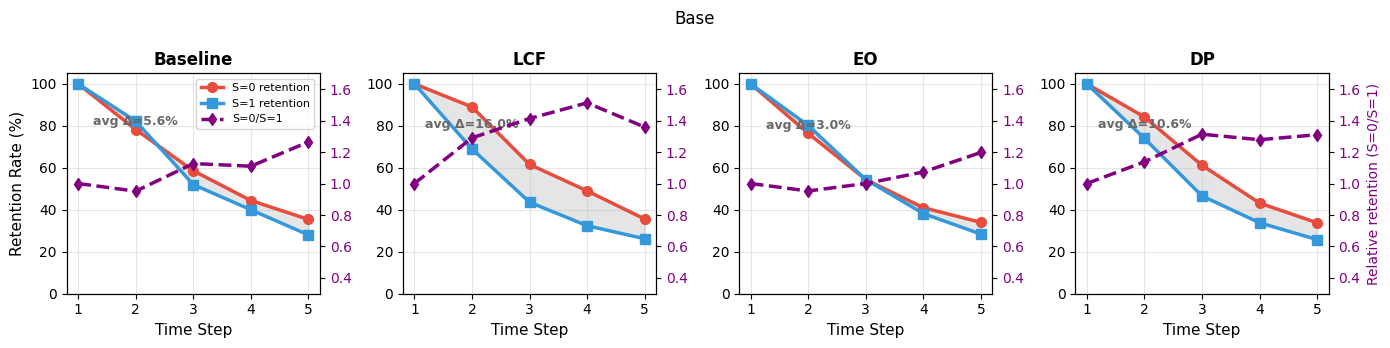

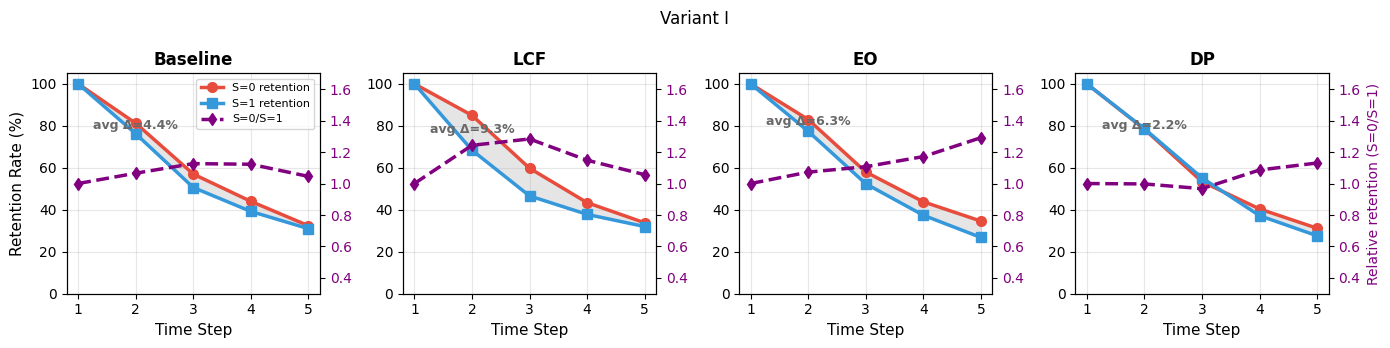

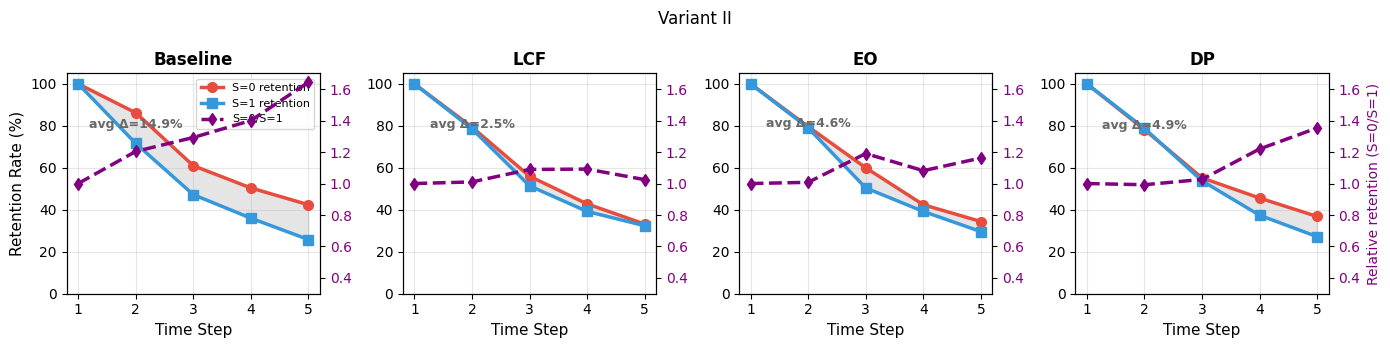

In [28]:
def plot_relative_retention(dataset_name, experiment):
    results = experiment['metrics']
    results_no_dynamic = experiment['metrics_no_opt_out']
    all_metrics = experiment.get('detailed_metrics', {})
    steps = list(range(1, len(results['Baseline']['S=0']) + 1))
    methods = list(results)
    method_colors = {'Baseline': '#E74C3C', 'LCF': '#3498DB', 'EO': '#27AE60', 'DP': '#9B59B6'}
    dataset_slug = {'Base': 'base', 'Variant I': 'variant1', 'Variant II': 'variant2'}[dataset_name]
    # Figure 2 Retention by group + relative retention ratio (twin axis, 4-panel)
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    left_colors = {'S=0': '#E74C3C', 'S=1': '#3498DB'}
    ratio_color = 'purple'

    for idx, method in enumerate(methods):
        ax = axes[idx]
        ax2 = ax.twinx()

        s0 = np.array(results[method]['S=0'], dtype=float)
        s1 = np.array(results[method]['S=1'], dtype=float)
        ratio = np.divide(s0, s1, out=np.full_like(s0, np.nan), where=(s1 != 0))

        l1, = ax.plot(steps, s0, 'o-', color=left_colors['S=0'], label='S=0 retention', linewidth=2.5, markersize=7)
        l2, = ax.plot(steps, s1, 's-', color=left_colors['S=1'], label='S=1 retention', linewidth=2.5, markersize=7)
        ax.fill_between(steps, s0, s1, alpha=0.2, color='gray')
        l3, = ax2.plot(steps, ratio, 'd--', color=ratio_color, label='S=0/S=1', linewidth=2.5, markersize=6)

        #disparity_t2 = results[method]['disparity'][1]
        avg_disparity = np.mean(results[method]['disparity'][1:])   # skip step 1 which is always 0, average for t 2-5
        mid_y = (s0[1] + s1[1]) / 2
        ax.annotate(f'avg Δ={avg_disparity:.1f}%', xy=(2, mid_y), fontsize=9, ha='center', color='dimgray', fontweight='bold')

        ax.set_title(method, fontsize=12, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.set_xticks(steps)
        ax.set_xlabel('Time Step', fontsize=11)
        ax.grid(True, alpha=0.3)

        if idx == len(methods) - 1:
            ax2.set_ylabel('Relative retention (S=0/S=1)', fontsize=10, color=ratio_color)
        ax2.tick_params(axis='y', labelcolor=ratio_color)
        ax2.set_ylim(0.3, 1.7)

        if idx == 0:
            ax.set_ylabel('Retention Rate (%)', fontsize=11)
            ax.legend(handles=[l1, l2, l3], loc='upper right', fontsize=8)

    fig.suptitle(dataset_name)
    plt.tight_layout()
    plt.show()

for dataset_name, experiment in experiments.items():
    plot_relative_retention(dataset_name, experiment)


## Plot long-term unfairness across models

Compare absolute long-term unfairness trajectories in one figure and save PNG and PDF copies.

Repeat the plot for all three datasets, label each figure, and prefix any saved filenames with the dataset name.


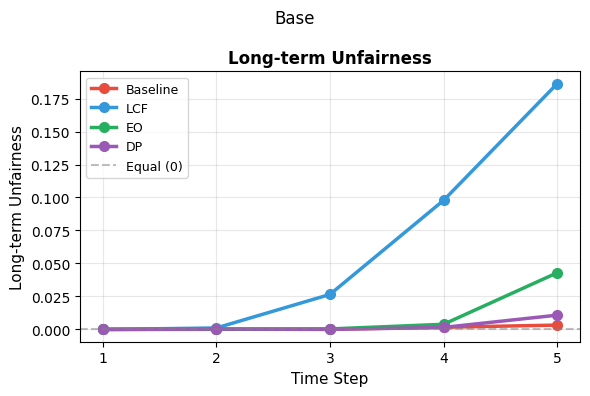

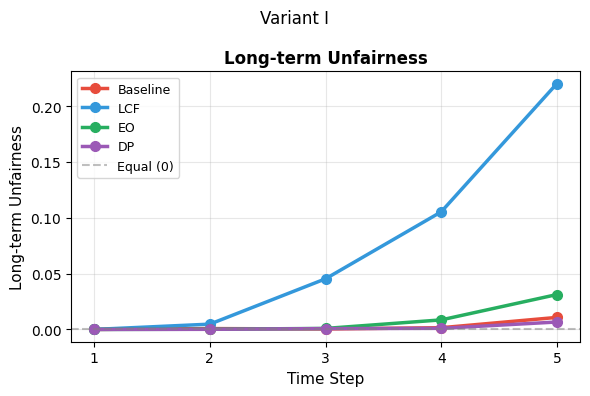

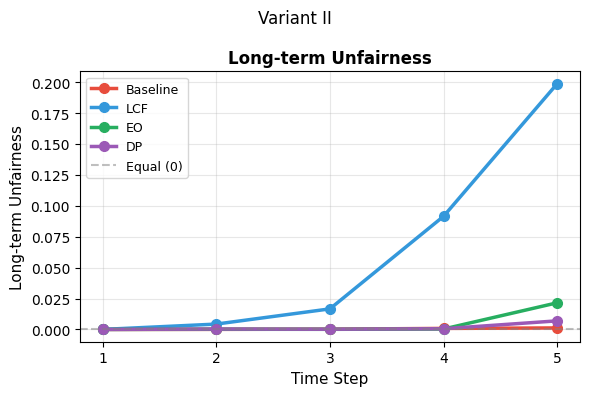

In [29]:
def plot_long_term_unfairness(dataset_name, experiment):
    results = experiment['metrics']
    results_no_dynamic = experiment['metrics_no_opt_out']
    all_metrics = experiment.get('detailed_metrics', {})
    steps = list(range(1, len(results['Baseline']['S=0']) + 1))
    methods = list(results)
    method_colors = {'Baseline': '#E74C3C', 'LCF': '#3498DB', 'EO': '#27AE60', 'DP': '#9B59B6'}
    dataset_slug = {'Base': 'base', 'Variant I': 'variant1', 'Variant II': 'variant2'}[dataset_name]
    # Figure 3 Merged long-term unfairness (single plot)
    method_colors = {'Baseline': '#E74C3C', 'LCF': '#3498DB', 'EO': '#27AE60', 'DP': '#9B59B6', 'PE': '#F39C12' }

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    for method in methods:
        ax.plot(steps, results[method]['unfairness'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)

    ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, label='Equal (0)')
    ax.set_xlabel('Time Step', fontsize=11)
    ax.set_ylabel('Long-term Unfairness', fontsize=11)
    ax.set_title('Long-term Unfairness', fontsize=12, fontweight='bold')
    ax.set_xticks(steps)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.suptitle(dataset_name)
    plt.tight_layout()
    plt.savefig(f'{dataset_slug}_long_term_unfairness_merged.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{dataset_slug}_long_term_unfairness_merged.pdf', bbox_inches='tight')
    plt.show()


for dataset_name, experiment in experiments.items():
    plot_long_term_unfairness(dataset_name, experiment)


## Compare unfairness with and without opt-out

Plot both participation settings, separating LCF onto its own axis so its scale does not obscure the other models.

Repeat the plot for all three datasets, label each figure, and prefix any saved filenames with the dataset name.


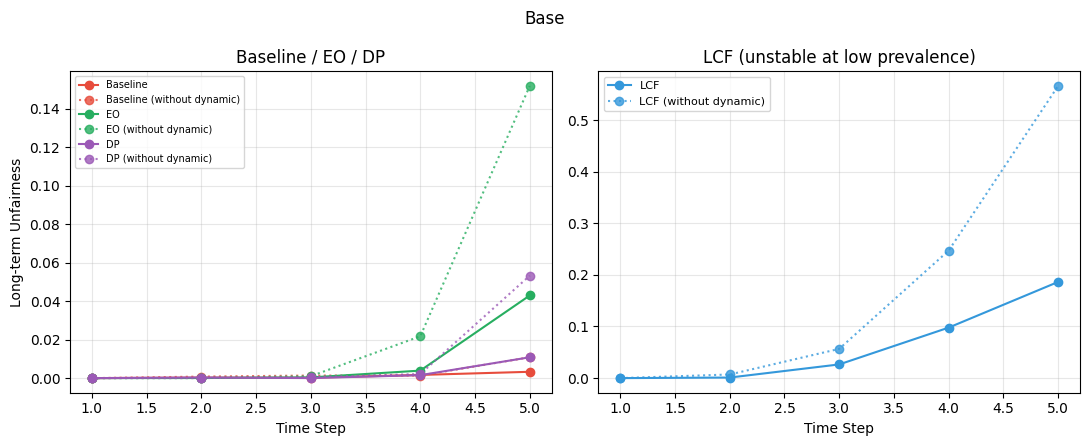

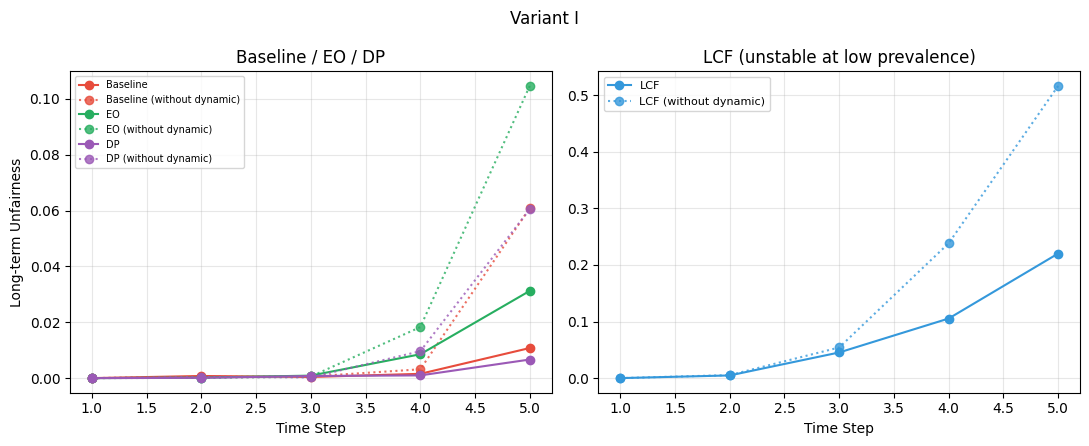

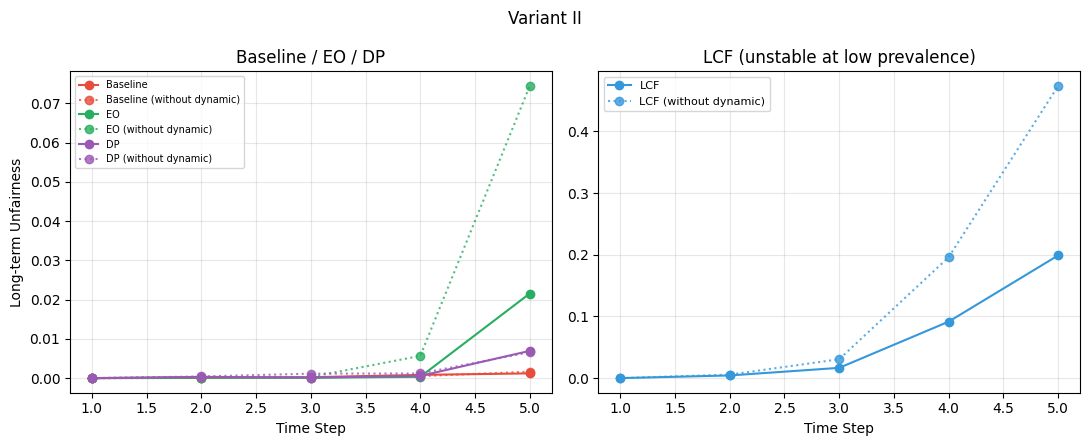

In [30]:
def plot_opt_out_comparison(dataset_name, experiment):
    results = experiment['metrics']
    results_no_dynamic = experiment['metrics_no_opt_out']
    all_metrics = experiment.get('detailed_metrics', {})
    steps = list(range(1, len(results['Baseline']['S=0']) + 1))
    methods = list(results)
    method_colors = {'Baseline': '#E74C3C', 'LCF': '#3498DB', 'EO': '#27AE60', 'DP': '#9B59B6'}
    dataset_slug = {'Base': 'base', 'Variant I': 'variant1', 'Variant II': 'variant2'}[dataset_name]
    # fig separating LCF from others to avoid stretching y-axis.
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # Left: everything except LCF
    for method in ['Baseline', 'EO', 'DP']:
        axes[0].plot(steps, results[method]['unfairness'], 'o-', color=method_colors[method], label=method)
        axes[0].plot(steps, results_no_dynamic[method]['unfairness'], 'o:', color=method_colors[method],
                     label=f'{method} (without dynamic)', alpha=0.8)
    axes[0].set_title('Baseline / EO / DP'); axes[0].set_xlabel('Time Step'); axes[0].set_ylabel('Long-term Unfairness')
    axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

    # Right: LCF alone, own scale
    axes[1].plot(steps, results['LCF']['unfairness'], 'o-', color=method_colors['LCF'], label='LCF')
    axes[1].plot(steps, results_no_dynamic['LCF']['unfairness'], 'o:', color=method_colors['LCF'],
                 label='LCF (without dynamic)', alpha=0.8)
    axes[1].set_title('LCF (unstable at low prevalence)')
    axes[1].set_xlabel('Time Step'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    fig.suptitle(dataset_name)
    plt.tight_layout()
    plt.show()

for dataset_name, experiment in experiments.items():
    plot_opt_out_comparison(dataset_name, experiment)


## Tabulate participation and approval metrics

Reuse stored trajectories to report active group counts, retention ratios, stepwise retention, and signed approval-rate differences among active applicants.


In [31]:
# Detailed metrics table reuses results_lr/lcf/eo/dp directly,
# NO second run_simulation() call needed (the original notebook's run_and_store() duplicated work that results_lr/lcf/eo/dp already contain).
def compute_detailed_metrics(s, As, Ds, Ys):
    s = np.array(s)
    n_s0_total = np.sum(s == 0)
    n_s1_total = np.sum(s == 1)

    print("Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)")
    print("-" * 120)

    metrics = {'s0_share': [], 'rep_ratio': [], 'signed_delta': [], 'retention_s0': [], 'retention_s1': [],
               'disparity': [], 'h_s0': [], 'h_s1': [], 'h_ratio': []}

    prev_active_s0 = prev_active_s1 = None

    for t in range(len(As)):
        A_t = np.array(As[t])
        D_t = np.array(Ds[t])

        active_s0 = np.sum((s == 0) & (A_t == 1))
        active_s1 = np.sum((s == 1) & (A_t == 1))
        total_active = active_s0 + active_s1
        s0_share = active_s0 / total_active if total_active > 0 else 0

        retention_s0 = (active_s0 / n_s0_total) * 100 if n_s0_total > 0 else np.nan
        retention_s1 = (active_s1 / n_s1_total) * 100 if n_s1_total > 0 else np.nan
        disparity = abs(retention_s0 - retention_s1)
        rep_ratio = retention_s0 / retention_s1 if retention_s1 and retention_s1 > 0 else np.nan

        if t == 0:
            h_s0 = h_s1 = 1.0
        else:
            h_s0 = (active_s0 / prev_active_s0) if (prev_active_s0 is not None and prev_active_s0 > 0) else np.nan
            h_s1 = (active_s1 / prev_active_s1) if (prev_active_s1 is not None and prev_active_s1 > 0) else np.nan
        h_ratio = (h_s0 / h_s1) if (h_s1 is not None and not np.isnan(h_s1) and h_s1 != 0) else np.nan

        prev_active_s0, prev_active_s1 = active_s0, active_s1

        active_mask = A_t == 1
        if active_s0 > 0 and active_s1 > 0:
            approval_s0 = np.mean(D_t[(s == 0) & active_mask])
            approval_s1 = np.mean(D_t[(s == 1) & active_mask])
            signed_delta = approval_s0 - approval_s1
        else:
            signed_delta = np.nan

        for k, v in zip(['s0_share','rep_ratio','signed_delta','retention_s0','retention_s1','disparity','h_s0','h_s1','h_ratio'],
                         [s0_share, rep_ratio, signed_delta, retention_s0, retention_s1, disparity, h_s0, h_s1, h_ratio]):
            metrics[k].append(v)

        print(f"  {t+1}  |  {active_s0:4d}  |  {active_s1:4d}  |   {s0_share:.2f}    |    {rep_ratio:6.2f}  |"
              f"  {h_s0:5.2f}  |  {h_s1:5.2f}  |  {h_ratio:6.2f}  |      {signed_delta:+.3f}")

    return metrics


def collect_detailed_metrics(trajectories):
    metrics = {}
    for model_name, (s, Xs, Ys, Ds, As) in trajectories.items():
        print(f'\n=== {model_name} ===')
        metrics[model_name] = compute_detailed_metrics(s, As, Ds, Ys)
    return metrics


detailed_metrics_base = collect_detailed_metrics(trajectories_base)
detailed_metrics_variant1 = collect_detailed_metrics(trajectories_variant1)
detailed_metrics_variant2 = collect_detailed_metrics(trajectories_variant2)

experiments['Base']['detailed_metrics'] = detailed_metrics_base
experiments['Variant I']['detailed_metrics'] = detailed_metrics_variant1
experiments['Variant II']['detailed_metrics'] = detailed_metrics_variant2



=== Baseline ===
Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)
------------------------------------------------------------------------------------------------------------------------
  1  |   500  |   500  |   0.50    |      1.00  |   1.00  |   1.00  |    1.00  |      -0.038
  2  |   391  |   411  |   0.49    |      0.95  |   0.78  |   0.82  |    0.95  |      +0.106
  3  |   293  |   260  |   0.53    |      1.13  |   0.75  |   0.63  |    1.18  |      +0.006
  4  |   222  |   200  |   0.53    |      1.11  |   0.76  |   0.77  |    0.98  |      +0.158
  5  |   177  |   140  |   0.56    |      1.26  |   0.80  |   0.70  |    1.14  |      +0.041

=== LCF ===
Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)
------------------------------------------------------------------------------------------------------------------------
  1  |   500  |   500  |   0.50    |      1.00  |   1.00  |   1.00  

## Plot participation ratios and approval differences

Plot and save relative retention, signed approval-rate differences, and stepwise retention ratios for each model.

Repeat the plot for all three datasets, label each figure, and prefix any saved filenames with the dataset name.


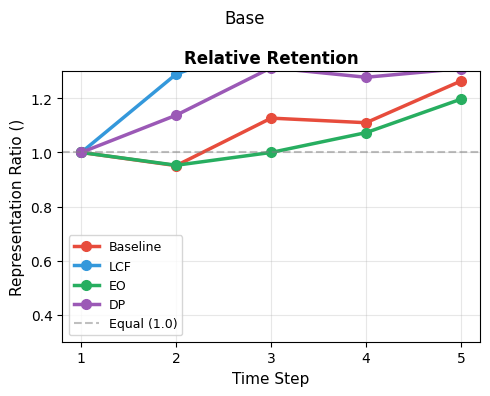

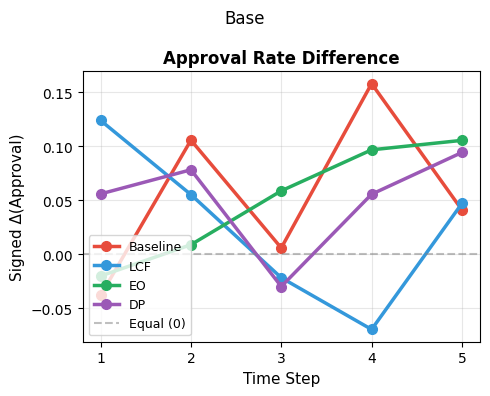

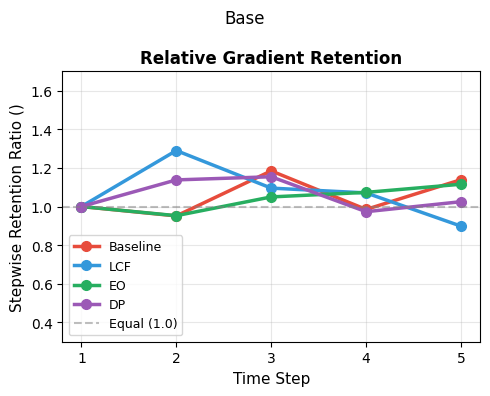

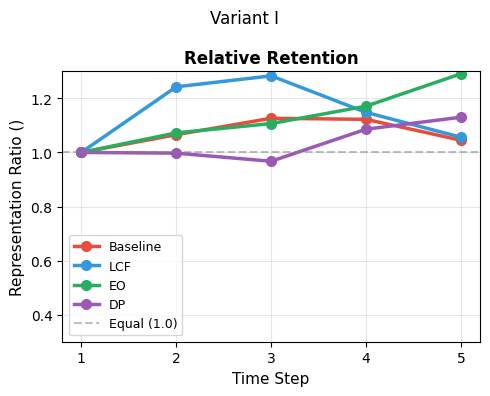

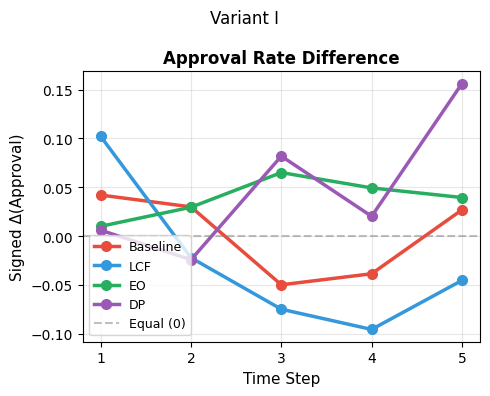

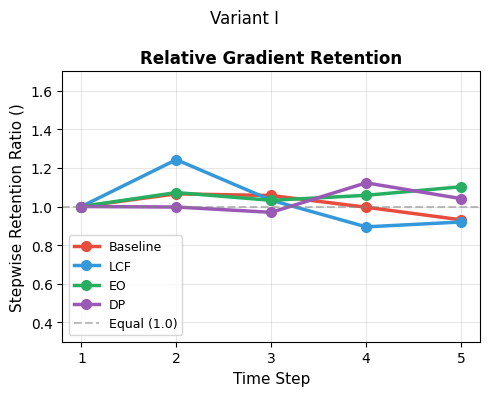

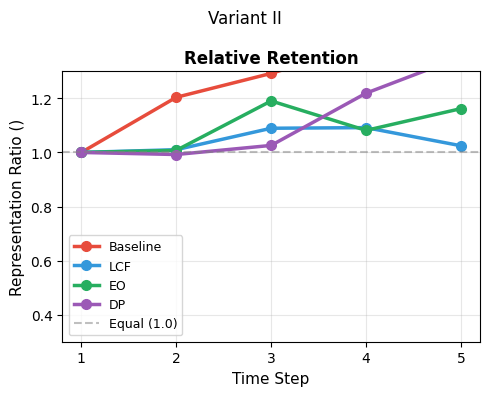

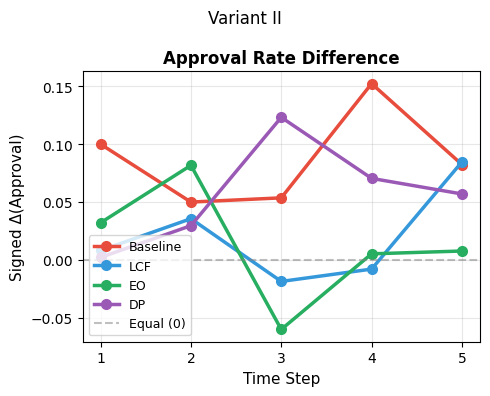

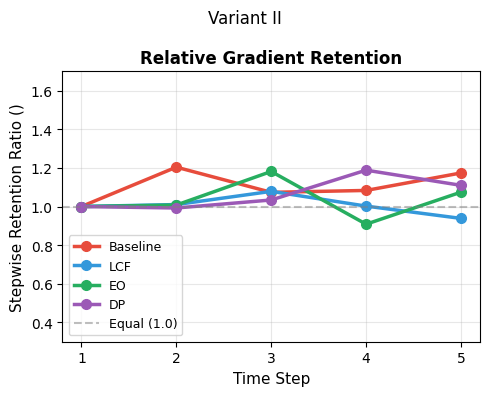

In [32]:
def plot_detailed_metrics(dataset_name, experiment):
    results = experiment['metrics']
    results_no_dynamic = experiment['metrics_no_opt_out']
    all_metrics = experiment.get('detailed_metrics', {})
    steps = list(range(1, len(results['Baseline']['S=0']) + 1))
    methods = list(results)
    method_colors = {'Baseline': '#E74C3C', 'LCF': '#3498DB', 'EO': '#27AE60', 'DP': '#9B59B6'}
    dataset_slug = {'Base': 'base', 'Variant I': 'variant1', 'Variant II': 'variant2'}[dataset_name]
    # Figures 4-6 -- H-linecharts (rep_ratio, signed_delta, h_ratio)
    single_figsize = (5, 4)

    fig, ax = plt.subplots(1, 1, figsize=single_figsize)
    for method in methods:
        ax.plot(steps, all_metrics[method]['rep_ratio'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal (1.0)')
    ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Representation Ratio ()', fontsize=11)
    ax.set_title('Relative Retention', fontsize=12, fontweight='bold')
    ax.set_ylim(0.3, 1.3); ax.set_xticks(steps); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
    fig.suptitle(dataset_name)
    plt.tight_layout(); plt.savefig(f'{dataset_slug}_relative_retention.png', dpi=300, bbox_inches='tight'); plt.savefig(f'{dataset_slug}_relative_retention.pdf', bbox_inches='tight'); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=single_figsize)
    for method in methods:
        ax.plot(steps, all_metrics[method]['signed_delta'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Equal (0)')
    ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Signed Δ(Approval)', fontsize=11)
    ax.set_title('Approval Rate Difference', fontsize=12, fontweight='bold')
    ax.set_xticks(steps); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
    fig.suptitle(dataset_name)
    plt.tight_layout(); plt.savefig(f'{dataset_slug}_approval_rate_difference.png', dpi=300, bbox_inches='tight'); plt.savefig(f'{dataset_slug}_approval_rate_difference.pdf', bbox_inches='tight'); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=single_figsize)
    for method in methods:
        ax.plot(steps, all_metrics[method]['h_ratio'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal (1.0)')
    ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Stepwise Retention Ratio ()', fontsize=11)
    ax.set_title('Relative Gradient Retention', fontsize=12, fontweight='bold')
    ax.set_xticks(steps); ax.set_ylim(0.3, 1.7); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
    fig.suptitle(dataset_name)
    plt.tight_layout(); plt.savefig(f'{dataset_slug}_relative_gradient_retention.png', dpi=300, bbox_inches='tight'); plt.savefig(f'{dataset_slug}_relative_gradient_retention.pdf', bbox_inches='tight'); plt.show()

for dataset_name, experiment in experiments.items():
    plot_detailed_metrics(dataset_name, experiment)


## Define seeded evaluation without opt-out

Define helpers that repeat simulations without population exit and summarize final approval-rate disparity across seeds. This differs from the retention-disparity summary used with opt-out.


In [33]:
def run_no_dynamic_seeded(model, model_name, bank, agent, steps=5, run_seed=2026):
    np.random.seed(run_seed)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=run_seed,
        seed=run_seed,
        decision_coef=0.8,
        repayment_coef=0.8,
    )
    return s, Xs, Ys, Ds, As


def run_multiseed_no_dynamic(model, model_name, bank, agent, steps=5, seeds=(2026, 7, 13, 42, 99)):
    disparities = []
    for sd in seeds:
        s, Xs, Ys, Ds, As = run_no_dynamic_seeded(model, model_name, bank, agent, steps, sd)
        s_arr = np.array(s)
        D_final = np.array(Ds[-1])
        approval_s0 = D_final[s_arr == 0].mean() * 100
        approval_s1 = D_final[s_arr == 1].mean() * 100
        disparities.append(abs(approval_s0 - approval_s1))
    return np.mean(disparities), np.std(disparities), disparities

## Compare approval disparity without opt-out

Print the mean, standard deviation, and individual final approval-rate disparities for each model across five seeds.


In [34]:
for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: approval disparity without opt-out ===')
    experiment['approval_disparity_no_opt_out'] = {}
    for model_name, model in experiment['models'].items():
        summary = run_multiseed_no_dynamic(model, model_name, experiment['bank'], experiment['test_agent'])
        experiment['approval_disparity_no_opt_out'][model_name] = summary
        mean_d, std_d, all_d = summary
        print(f"{model_name}: {mean_d:.1f}% ± {std_d:.1f}% (runs: {[round(x, 1) for x in all_d]})")



=== Base: approval disparity without opt-out ===
Baseline: 8.0% ± 3.9% (runs: [np.float64(5.2), np.float64(9.2), np.float64(15.0), np.float64(6.0), np.float64(4.4)])
LCF: 4.6% ± 5.0% (runs: [np.float64(1.4), np.float64(8.2), np.float64(12.8), np.float64(0.8), np.float64(0.0)])
EO: 7.3% ± 4.7% (runs: [np.float64(4.2), np.float64(10.8), np.float64(14.8), np.float64(4.4), np.float64(2.2)])
DP: 8.3% ± 4.8% (runs: [np.float64(5.2), np.float64(11.4), np.float64(16.2), np.float64(6.0), np.float64(2.8)])

=== Variant I: approval disparity without opt-out ===
Baseline: 8.5% ± 4.6% (runs: [np.float64(6.0), np.float64(11.2), np.float64(16.2), np.float64(5.4), np.float64(3.6)])
LCF: 3.6% ± 1.3% (runs: [np.float64(1.6), np.float64(3.2), np.float64(5.8), np.float64(3.4), np.float64(3.8)])
EO: 7.4% ± 4.2% (runs: [np.float64(4.6), np.float64(11.0), np.float64(13.8), np.float64(4.6), np.float64(3.0)])
DP: 8.5% ± 4.6% (runs: [np.float64(6.0), np.float64(11.2), np.float64(16.2), np.float64(5.4), np.floa

## Compare final unfairness across seeds

Summarize final long-term unfairness with and without opt-out. These calls use the shared loop’s default mixing of six same-group and four other-group neighbors.


In [35]:
def unfairness_multiseed(model, bank, agent, dynamic=True, seeds=(2026, 7, 13, 42, 99)):
    finals = []
    for sd in seeds:
        np.random.seed(sd)
        if dynamic:
            s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
                model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        else:
            s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
                model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        m = extract_metrics((s, Xs, Ys, Ds, As), model)
        finals.append(m['unfairness'][-1])
    return np.mean(finals), np.std(finals), finals


for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: final long-term unfairness ===')
    experiment['unfairness_summary'] = {}
    for model_name, model in experiment['models'].items():
        with_opt_out = unfairness_multiseed(model, experiment['bank'], experiment['test_agent'], dynamic=True)
        without_opt_out = unfairness_multiseed(model, experiment['bank'], experiment['test_agent'], dynamic=False)
        experiment['unfairness_summary'][model_name] = {'with_opt_out': with_opt_out, 'without_opt_out': without_opt_out}
        m_with, s_with, _ = with_opt_out
        m_without, s_without, _ = without_opt_out
        print(f"{model_name}: with={m_with:.3f}±{s_with:.3f} without={m_without:.3f}±{s_without:.3f} ratio={m_without/m_with:.1f}x")



=== Base: final long-term unfairness ===
Baseline: with=0.004±0.002 without=0.010±0.003 ratio=2.3x
LCF: with=0.216±0.014 without=0.573±0.004 ratio=2.6x
EO: with=0.042±0.009 without=0.145±0.009 ratio=3.4x
DP: with=0.015±0.006 without=0.049±0.004 ratio=3.2x

=== Variant I: final long-term unfairness ===
Baseline: with=0.016±0.006 without=0.057±0.007 ratio=3.6x
LCF: with=0.188±0.017 without=0.521±0.006 ratio=2.8x
EO: with=0.025±0.007 without=0.095±0.008 ratio=3.8x
DP: with=0.016±0.006 without=0.057±0.007 ratio=3.7x

=== Variant II: final long-term unfairness ===
Baseline: with=0.003±0.002 without=0.001±0.002 ratio=0.5x
LCF: with=0.171±0.010 without=0.475±0.007 ratio=2.8x
EO: with=0.021±0.008 without=0.078±0.004 ratio=3.6x
DP: with=0.005±0.002 without=0.018±0.002 ratio=3.3x


## Summarize average retention disparity across seeds

Average each run’s retention disparities after the initial step, then report the mean and standard deviation across seeds. These calls also use the default six/four neighborhood mixing.


In [36]:
def avg_disparity_seeded(model, bank, agent, seeds=(2026, 7, 13, 42, 99)):
    avg_disparities = []
    for sd in seeds:
        np.random.seed(sd)
        s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
            model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        s_arr = np.array(s)
        step_disparities = []
        for A_t in As:
            A_t = np.array(A_t)
            r0 = A_t[s_arr == 0].mean() * 100
            r1 = A_t[s_arr == 1].mean() * 100
            step_disparities.append(abs(r0 - r1))
        avg_disparities.append(np.mean(step_disparities[1:]))  # skip step 1, always 0
    return np.mean(avg_disparities), np.std(avg_disparities), avg_disparities


for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: average retention disparity ===')
    experiment['average_retention_disparity'] = {}
    for model_name, model in experiment['models'].items():
        summary = avg_disparity_seeded(model, experiment['bank'], experiment['test_agent'])
        experiment['average_retention_disparity'][model_name] = summary
        mean_d, std_d, all_d = summary
        print(f"{model_name}: avg_disparity={mean_d:.1f}±{std_d:.1f} (runs: {[round(x, 1) for x in all_d]})")



=== Base: average retention disparity ===
Baseline: avg_disparity=11.0±2.1 (runs: [np.float64(10.6), np.float64(12.1), np.float64(14.4), np.float64(8.3), np.float64(9.7)])
LCF: avg_disparity=5.0±3.5 (runs: [np.float64(5.8), np.float64(3.2), np.float64(11.6), np.float64(1.9), np.float64(2.6)])
EO: avg_disparity=4.4±1.6 (runs: [np.float64(2.3), np.float64(5.0), np.float64(7.2), np.float64(3.5), np.float64(3.9)])
DP: avg_disparity=7.6±1.7 (runs: [np.float64(6.9), np.float64(8.5), np.float64(10.5), np.float64(5.9), np.float64(6.3)])

=== Variant I: average retention disparity ===
Baseline: avg_disparity=5.1±2.1 (runs: [np.float64(3.5), np.float64(4.2), np.float64(9.2), np.float64(4.2), np.float64(4.6)])
LCF: avg_disparity=6.9±3.5 (runs: [np.float64(8.0), np.float64(2.4), np.float64(12.8), np.float64(5.2), np.float64(6.0)])
EO: avg_disparity=4.4±1.8 (runs: [np.float64(2.3), np.float64(3.3), np.float64(7.6), np.float64(4.9), np.float64(3.9)])
DP: avg_disparity=5.1±2.1 (runs: [np.float64(3.5